In [11]:
!pip install pyspark -q

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ETL_Viz") \
    .getOrCreate()

print("✅ Spark démarré :", spark.version)

✅ Spark démarré : 4.0.2


In [14]:
gold_pays = spark.read.parquet('/content/drive/MyDrive/ETL_projet/gold/ventes_par_pays/').toPandas()
gold_mois = spark.read.parquet('/content/drive/MyDrive/ETL_projet/gold/ventes_par_mois/').toPandas()
gold_produits = spark.read.parquet('/content/drive/MyDrive/ETL_projet/gold/top_produits/').toPandas()

print("✅ Tables Gold chargées !")

✅ Tables Gold chargées !


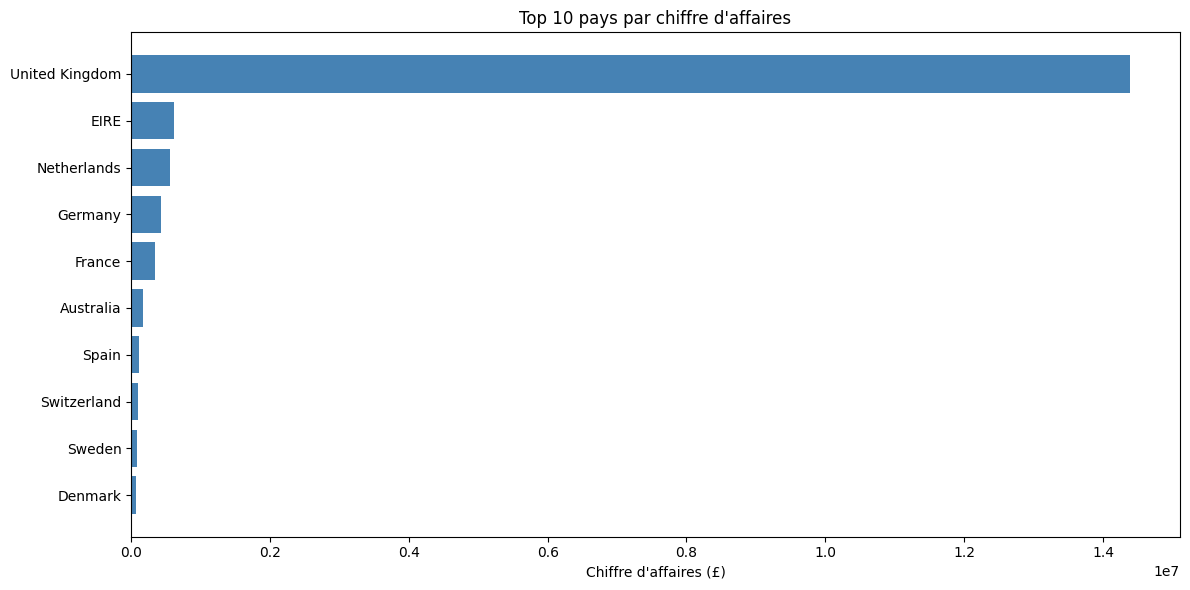

✅ Graphique 1 sauvegardé !


In [15]:
import matplotlib.pyplot as plt

top_pays = gold_pays.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_pays['Country'], top_pays['CA_total'], color='steelblue')
plt.xlabel("Chiffre d'affaires (£)")
plt.title("Top 10 pays par chiffre d'affaires")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ETL_projet/graphique_pays.png')
plt.show()
print("✅ Graphique 1 sauvegardé !")

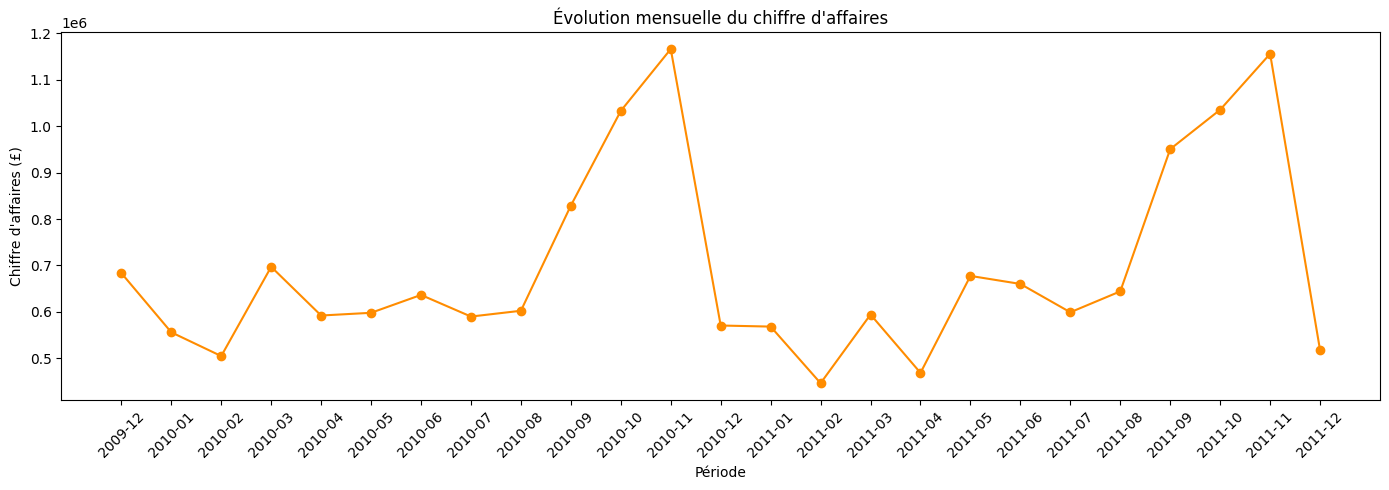

✅ Graphique 2 sauvegardé !


In [16]:
gold_mois['Periode'] = gold_mois['Annee'].astype(str) + '-' + gold_mois['Mois'].astype(str).str.zfill(2)
gold_mois = gold_mois.sort_values('Periode')

plt.figure(figsize=(14, 5))
plt.plot(gold_mois['Periode'], gold_mois['CA_mensuel'], marker='o', color='darkorange')
plt.xlabel("Période")
plt.ylabel("Chiffre d'affaires (£)")
plt.title("Évolution mensuelle du chiffre d'affaires")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ETL_projet/graphique_mois.png')
plt.show()
print("✅ Graphique 2 sauvegardé !")

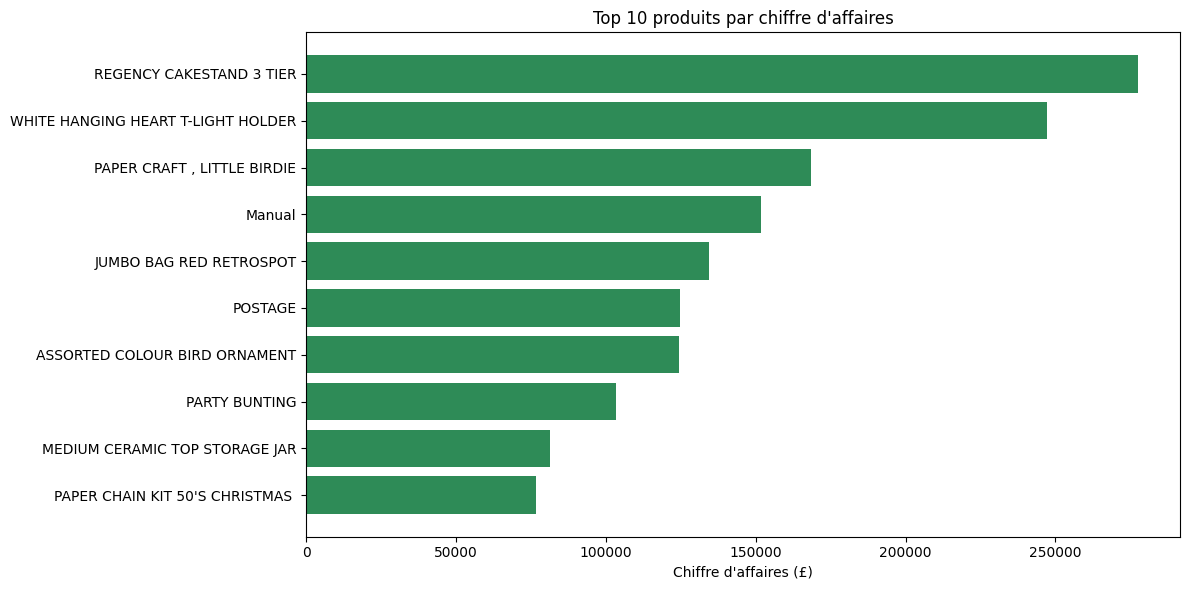

✅ Graphique 3 sauvegardé !


In [17]:
plt.figure(figsize=(12, 6))
plt.barh(gold_produits['Description'], gold_produits['CA_total'], color='seagreen')
plt.xlabel("Chiffre d'affaires (£)")
plt.title("Top 10 produits par chiffre d'affaires")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ETL_projet/graphique_produits.png')
plt.show()
print("✅ Graphique 3 sauvegardé !")

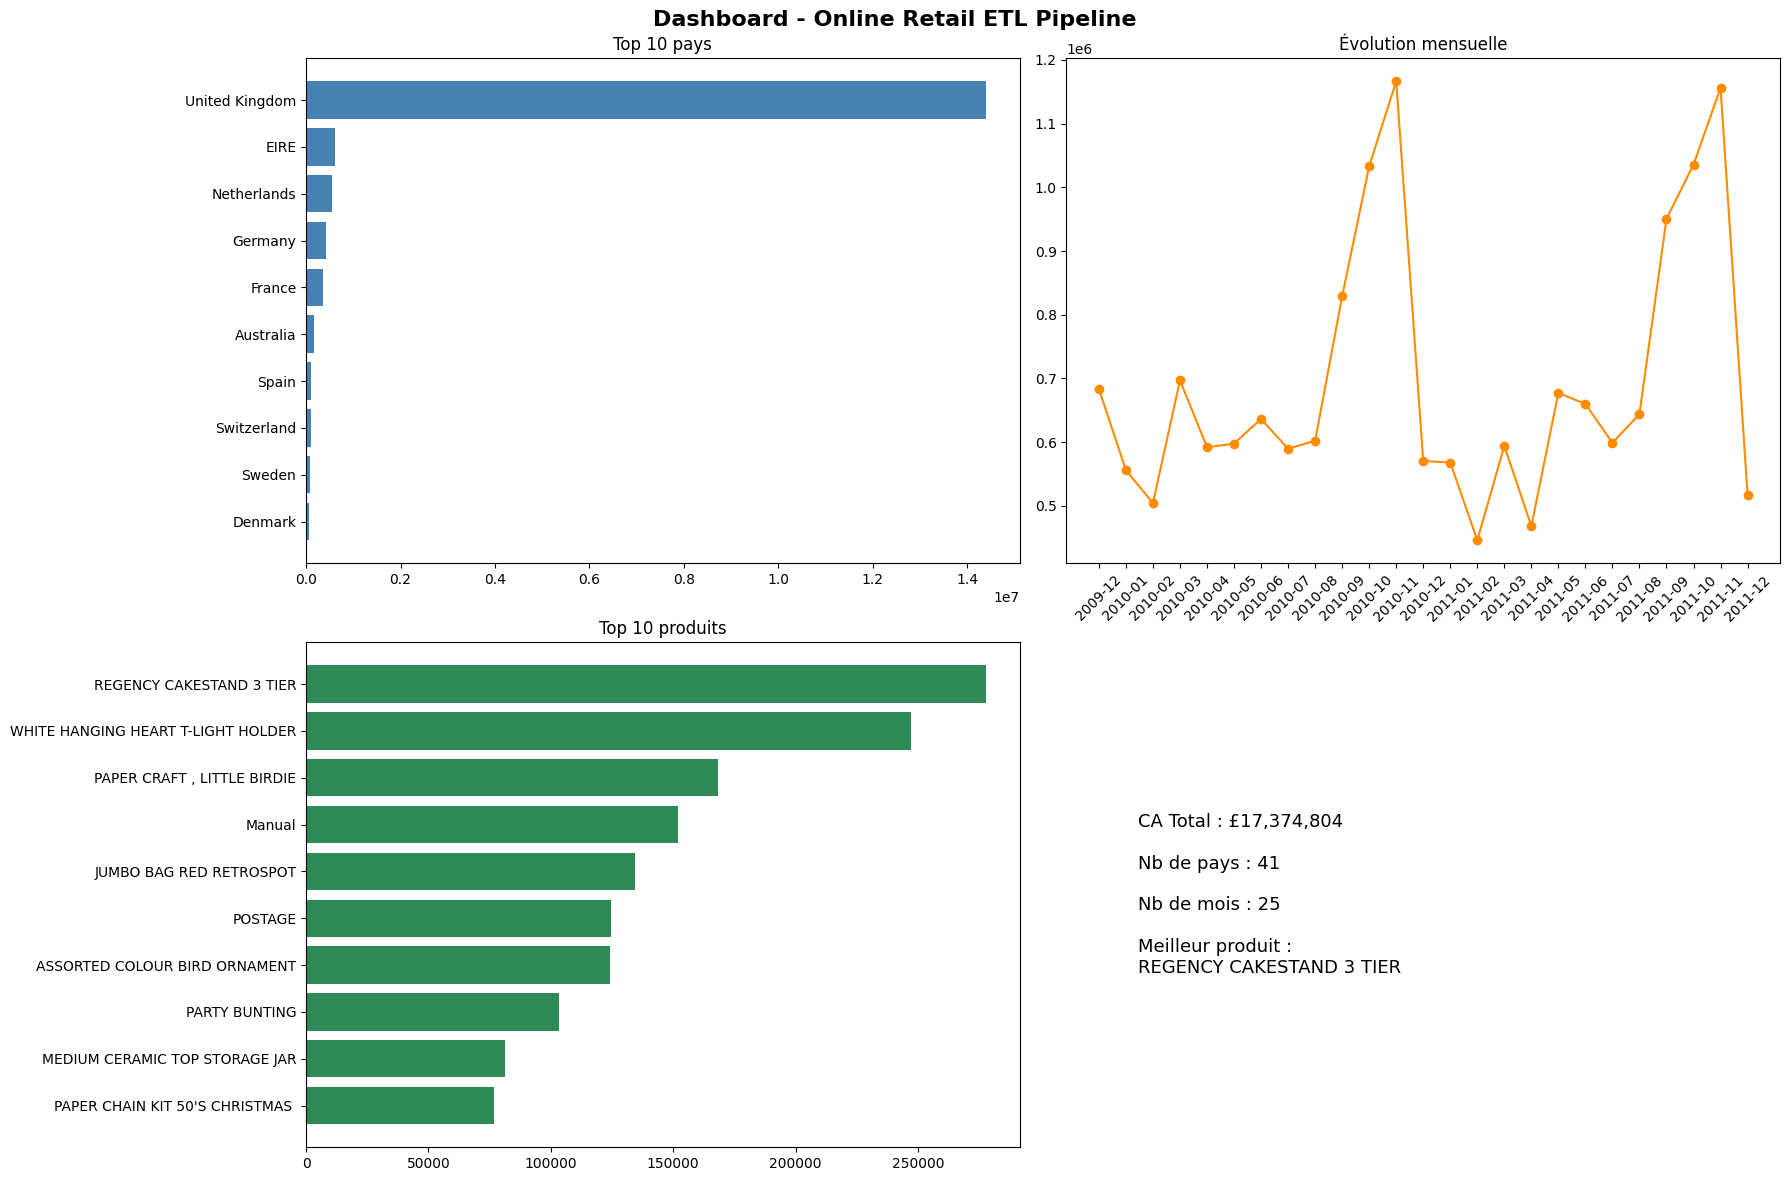

✅ Dashboard sauvegardé !


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Dashboard - Online Retail ETL Pipeline", fontsize=16, fontweight='bold')

# Graphique 1
axes[0, 0].barh(top_pays['Country'], top_pays['CA_total'], color='steelblue')
axes[0, 0].set_title("Top 10 pays")
axes[0, 0].invert_yaxis()

# Graphique 2
axes[0, 1].plot(gold_mois['Periode'], gold_mois['CA_mensuel'], marker='o', color='darkorange')
axes[0, 1].set_title("Évolution mensuelle")
axes[0, 1].tick_params(axis='x', rotation=45)

# Graphique 3
axes[1, 0].barh(gold_produits['Description'], gold_produits['CA_total'], color='seagreen')
axes[1, 0].set_title("Top 10 produits")
axes[1, 0].invert_yaxis()

# KPIs
axes[1, 1].axis('off')
kpi_text = f"""
CA Total : £{gold_pays['CA_total'].sum():,.0f}

Nb de pays : {len(gold_pays)}

Nb de mois : {len(gold_mois)}

Meilleur produit :
{gold_produits.iloc[0]['Description']}
"""
axes[1, 1].text(0.1, 0.5, kpi_text, fontsize=13, verticalalignment='center')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ETL_projet/dashboard.png')
plt.show()
print("✅ Dashboard sauvegardé !")